In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split


In [3]:
df = pd.read_csv('../sample_data/train.csv',usecols=['Age','Fare','Survived'])

In [4]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [5]:
df.isnull().mean()*100

Survived     0.00000
Age         19.86532
Fare         0.00000
dtype: float64

In [6]:
x=df.drop('Survived',axis=1)
y=df['Survived']

In [7]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [8]:
x_train['age_imputed'] = x_train['Age']
x_test['age_imputed'] = x_test['Age']



In [11]:
# TRAIN
mask_train = x_train['age_imputed'].isnull()
# print('mask_train',mask_train)
n_missing_train = mask_train.sum()
# print('missing train ',n_missing_train)


x_train.loc[mask_train, 'age_imputed'] = (
    x_train.loc[x_train['Age'].notnull(), 'Age']
    .sample(n_missing_train, random_state=42)
    .values
)

# TEST
mask_test = x_test['age_imputed'].isnull()
n_missing_test = mask_test.sum()

x_test.loc[mask_test, 'age_imputed'] = (
    x_test.loc[x_test['Age'].notnull(), 'Age']
    .sample(n_missing_test, random_state=42)
    .values
)


In [12]:
x_train.tail()

,Age,Fare,age_imputed
106,21.0,7.6500,21.0
270,NaN,31.0000,21.0
860,41.0,14.1083,41.0
435,14.0,120.0000,14.0
102,21.0,77.2875,21.0


<Axes: xlabel='Age', ylabel='Density'>

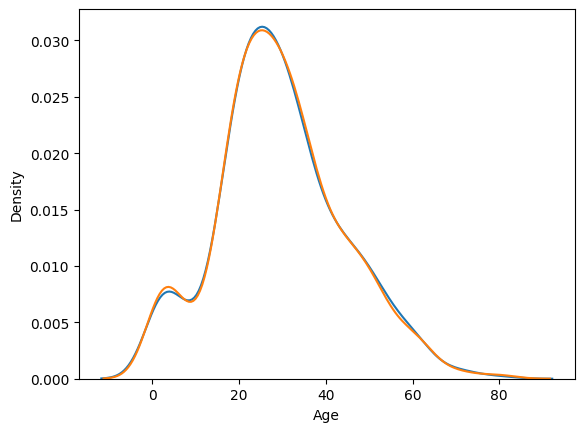

In [13]:
sns.kdeplot(x_train['Age'],label='original')
sns.kdeplot(x_train['age_imputed'],label='imputed')

In [15]:
print(x_train['Age'].var())
x_train['age_imputed'].var()

210.2517072477437


210.47357118159263

In [19]:
x_train[['Age','age_imputed','Fare']].cov()

,Age,age_imputed,Fare
Age,210.251707,210.251707,71.580633
age_imputed,210.251707,210.473571,54.857635
Fare,71.580633,54.857635,2700.831981


<Axes: >

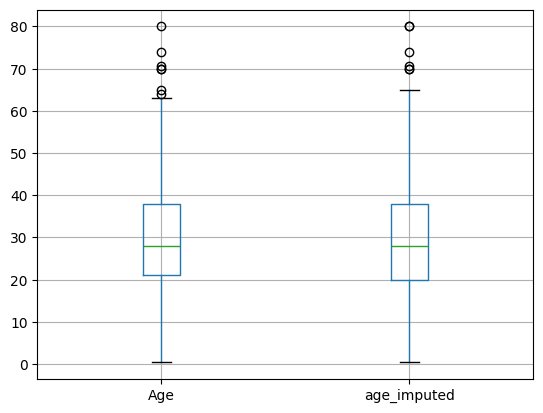

In [20]:
x_train[['Age','age_imputed']].boxplot()

what the code below does it ensures every tine for a parrticular age fare remain sames thru samr random int
Same Fare → same seed → same sampled Age (as long as the data doesn’t change)


In [22]:
def random_age_imputer(observation):
    if pd.isnull(observation['Age']):
        return x_train['Age'].dropna().sample(
            1,
            random_state=int(observation['Fare'])
        ).values[0]
    else:
        return observation['Age']
